In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
filePath = '/mnt/DataDrive3/emeyer/TreeShrewObjectRecognition/5_behaviorModeling/'
taskName = 'Camel_v2_test_nn' #'Camel_v2_test_nn' 'Camel_Rhino_test_nn' 'Camel_background_matrix'

df_pixel_orig = pd.read_csv(f'{filePath}distData/{taskName}/original_pixel_distances.csv', header=None)
df_pixelcenter_orig = pd.read_csv(f'{filePath}distData/{taskName}/register_centered_pixel_distances.csv', header=None)
df_pixelscale_orig = pd.read_csv(f'{filePath}distData/{taskName}/register_scaled_pixel_distances.csv', header=None)
df_pixelcenterscale_orig = pd.read_csv(f'{filePath}distData/{taskName}/register_centered_scaled_pixel_distances.csv', header=None)
df_gabor = pd.read_csv(f'{filePath}distData/{taskName}/gabor_distances_norm.csv', header=None)
df_isetbio_NN = pd.read_csv(f'{filePath}distData/{taskName}/isetbio_distances_combmodel.csv', header=None)
df_texture_inplace = pd.read_csv(f'{filePath}distData/{taskName}/texture_inplace_distances_combmodel.csv', header=None)
df_texture = pd.read_csv(f'{filePath}distData/{taskName}/texture_crop_distances_combmodel.csv', header=None)
df_skeleton = pd.read_csv(f'{filePath}distData/{taskName}/skeleton_distances_combmodel.csv', header=None)
df_skeleton_scaled = pd.read_csv(f'{filePath}distData/{taskName}/skeleton_scaled_distances_combmodel.csv', header=None)
df_salicon = pd.read_csv(f'{filePath}distData/{taskName}/salicon_distances_combmodel.csv', header=None)
df_behavior = pd.read_csv(f'{filePath}distData/{taskName}/treeshrew_behavior.csv', header=None)
df_alexnet_cont = pd.read_csv(f'{filePath}distData/{taskName}/alexnet_mouse_distances2.csv', header=None)
df_alexnet_sup = pd.read_csv(f'{filePath}distData/{taskName}/alexnet_distances2.csv', header=None)
df_vgg = pd.read_csv(f'{filePath}distData/{taskName}/vgg16_distances2.csv', header=None)

# Combine the dataframes into a single dataframe
df_combined = pd.concat([df_behavior, df_pixel_orig, df_pixelcenter_orig, df_pixelscale_orig,df_pixelcenterscale_orig, df_gabor, df_texture, df_texture_inplace, df_skeleton, df_skeleton_scaled, df_salicon, df_alexnet_cont, df_alexnet_sup, df_vgg], axis=1, ignore_index=True)
df_labels = ['Behavior', 'Pixel', 'Pixel Centered','Pixel Scaled','Pixel Centered, Scaled', 'Gabor', 'Texture','Texture In-Place', 'Skeleton','Scaled Skeleton','Salicon', 'Cont. AlexNet', 'Sup. AlexNet', 'VGG16']

In [8]:
# Set colors for each model where first four are shades of green, next five are shades of blue, and last three are shades of red
colors = ['#004d00', '#228B22', '#4CBB17', '#90EE90',  # Greens (darker to lighter)
          '#00005f', '#0000CD', '#4169E1', '#6495ED', '#87CEEB', '#B0E0E6',  # Blues (darker to lighter)
          '#8B0000', '#DC143C', '#FF6B6B']  # Reds (darker to lighter)

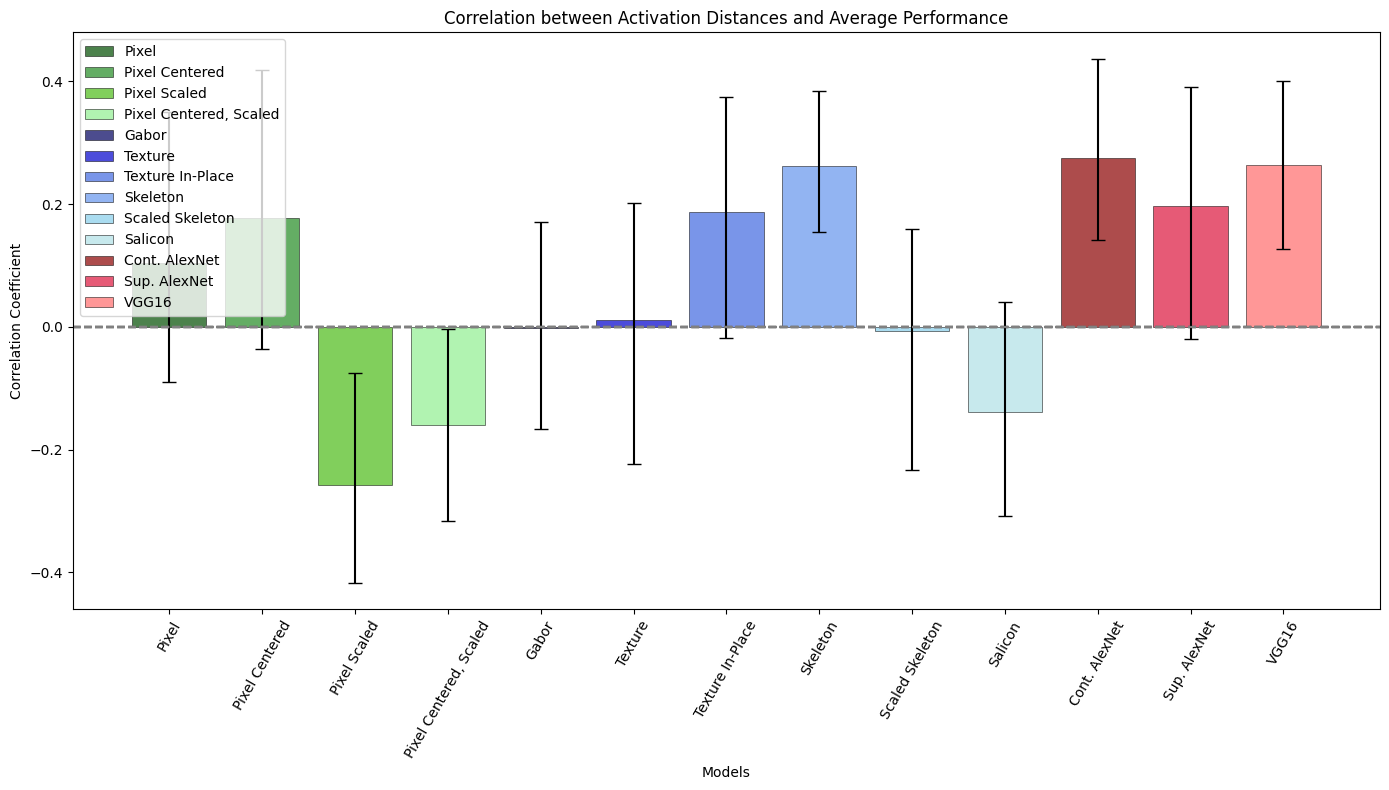

In [9]:
# Plot bar graph for each data set's correlation with behavior
plt.figure(figsize=(14, 8))
for i in range(len(df_labels)-1):
    # Calculate the correlation coefficient
    correlation = df_combined.corr().iloc[0, i+1]

    # Calculate the confidence interval with bootstrapping
    n_bootstraps = 1000
    bootstrapped_correlations = []
    for _ in range(n_bootstraps):
        # Resample the data with replacement
        resampled_data = df_combined.sample(frac=1, replace=True)
        # Calculate the correlation coefficient for the resampled data
        bootstrapped_correlation = resampled_data.corr().iloc[0, i+1]
        bootstrapped_correlations.append(bootstrapped_correlation)

    # Calculate the confidence interval
    ci_lower = np.percentile(bootstrapped_correlations, 2.5)
    ci_upper = np.percentile(bootstrapped_correlations, 97.5)

    # Plot bar graph for ech data set's correlation with behavior
    plt.bar(i, correlation, label=df_labels[i+1], alpha=0.7, color=colors[i], edgecolor='black', linewidth=0.5)
    plt.errorbar(i, correlation, yerr=[[correlation - ci_lower], [ci_upper - correlation]], fmt='', color='black', capsize=5)
    plt.xticks(range(len(df_labels)-1), df_labels[1:], rotation=60)
    plt.axhline(y=0, color='gray', linestyle='--')
    plt.title('Correlation between Activation Distances and Average Performance')
    plt.ylabel('Correlation Coefficient')
    plt.xlabel('Models')
    plt.legend()
    plt.tight_layout()

plt.savefig(f'{filePath}figures/{taskName}_bar_correlation.png', dpi=300)
plt.savefig(f'{filePath}figures/{taskName}_bar_correlation.svg', dpi=300)
plt.show()


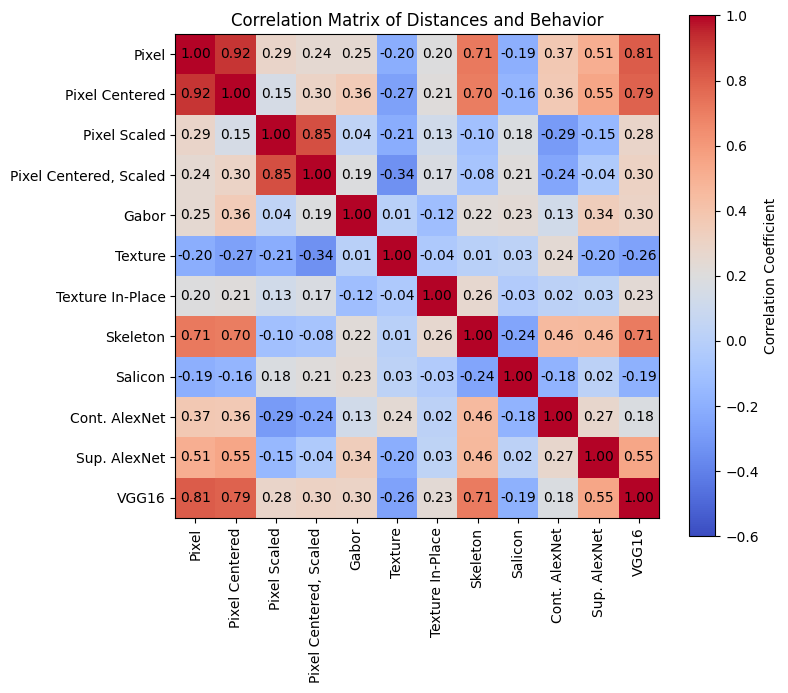

In [13]:
# Make correlation matrix with all columns of df_combined
correlation_matrix = df_combined.corr().iloc[1:, 1:]  # Exclude the first column (behavior)
# Set the labels for the heatmap
df_labels_red = df_labels[1:]
# df_labels = ['Pixel', 'Pixel Centered','Pixel Scaled','Pixel Centered, Scaled', 'Gabor', 'Texture','Salicon', 'Skeleton', 'VGG16', 'Cont. AlexNet', 'Sup. AlexNet']
# Set the figure size
plt.figure(figsize=(8, 7))
# Create a heatmap using the correlation matrix
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='nearest', vmin=-0.6, vmax=1)
# Display the correlation values on the heatmap
for (i, j), value in np.ndenumerate(correlation_matrix):
    plt.text(j, i, f'{value:.2f}', ha='center', va='center', color='black')
plt.colorbar(label='Correlation Coefficient')
plt.title('Correlation Matrix of Distances and Behavior')
plt.xticks(range(len(correlation_matrix.columns)), df_labels_red, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), df_labels_red)
plt.tight_layout()
plt.savefig(f'{filePath}figures/{taskName}_correlation_matrix.svg', dpi=300)
plt.savefig(f'{filePath}figures/{taskName}_correlation_matrix.png', dpi=300)
plt.show()

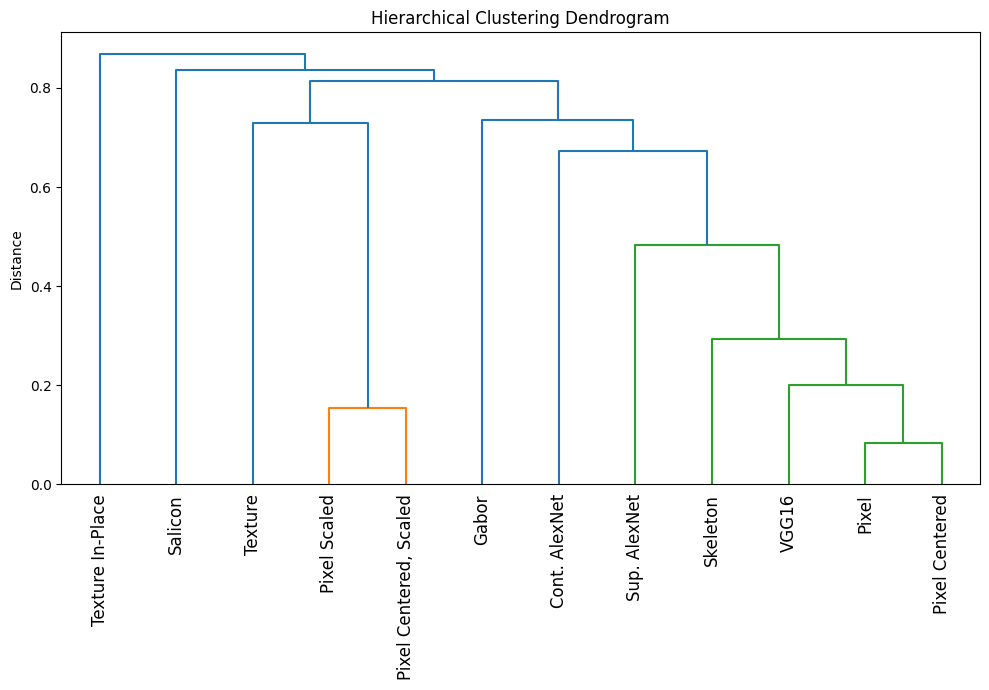

/tmp/ipykernel_2682017/3635222660.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


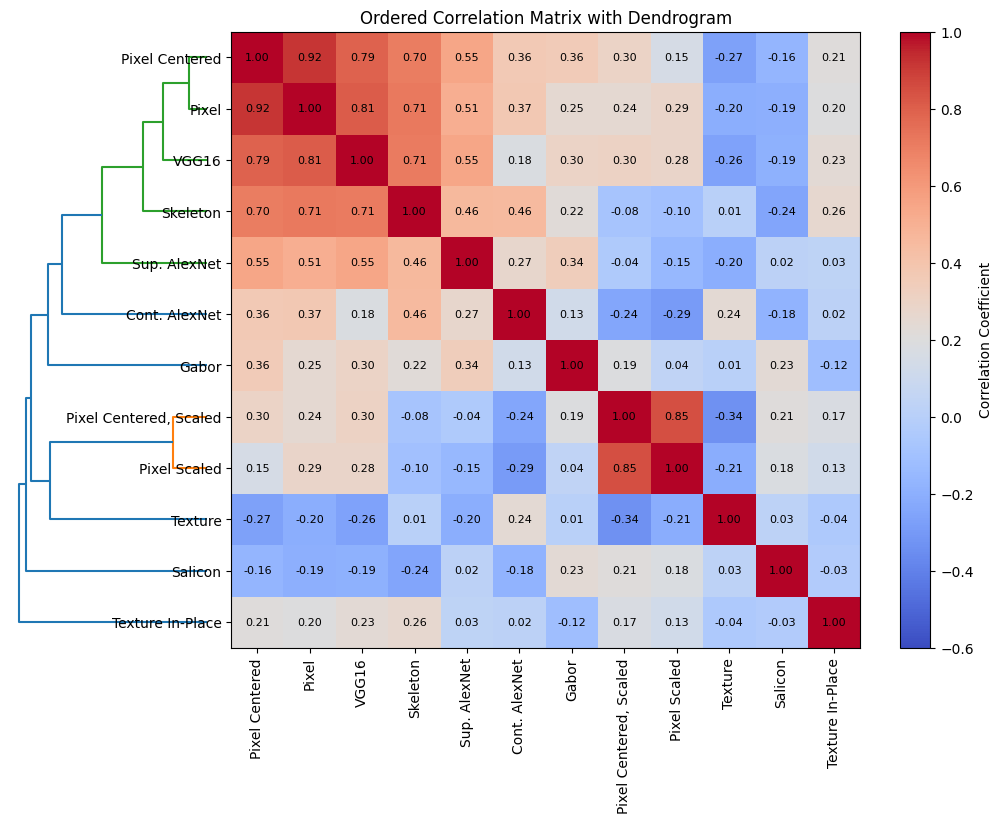

In [14]:
# # Make correlation matrix with all columns of df_combined
# correlation_matrix = df_combined.corr() # Exclude the first column (behavior)

# # Set the figure size
# plt.figure(figsize=(8, 7))
# # Create a heatmap using the correlation matrix
# plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='nearest', vmin=-0.6, vmax=1)
# # Display the correlation values on the heatmap
# for (i, j), value in np.ndenumerate(correlation_matrix):
#     plt.text(j, i, f'{value:.2f}', ha='center', va='center', color='black')
# plt.colorbar(label='Correlation Coefficient')
# plt.title('Correlation Matrix of Distances and Behavior')
# plt.xticks(range(len(correlation_matrix.columns)), df_labels, rotation=90)
# plt.yticks(range(len(correlation_matrix.columns)), df_labels)
# plt.tight_layout()
# plt.savefig(f'{filePath}figures/{taskName}_correlation_matrix.svg', dpi=300)
# plt.savefig(f'{filePath}figures/{taskName}_correlation_matrix.png', dpi=300)
# plt.show()

# Perform hierarchical clustering on the correlation matrix
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import dendrogram

# Convert the correlation matrix to a distance matrix
distance_matrix = 1 - correlation_matrix.abs()
# Perform hierarchical clustering
linked = sch.linkage(squareform(distance_matrix), method='average')
# Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram = sch.dendrogram(linked, labels=df_labels_red, orientation='top', leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

# Order the correlation matrix based on the clustering
ordered_indices = np.flip(dendrogram['leaves'])
ordered_correlation_matrix = correlation_matrix.iloc[ordered_indices, ordered_indices]
ordered_labels = [df_labels_red[i] for i in ordered_indices]

# Plot the ordered heatmap
import matplotlib.gridspec as gridspec

# Create figure with GridSpec for layout
fig = plt.figure(figsize=(13, 8))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 4], wspace=0.05)

# Plot dendrogram on the left
ax_dendro = fig.add_subplot(gs[0])
dendrogram_left = sch.dendrogram(linked, labels=df_labels_red, orientation='left', no_labels=True)
ax_dendro.set_xticks([])
ax_dendro.set_yticks([])
ax_dendro.spines['top'].set_visible(False)
ax_dendro.spines['right'].set_visible(False)
ax_dendro.spines['bottom'].set_visible(False)
ax_dendro.spines['left'].set_visible(False)

# Plot heatmap on the right
ax_heatmap = fig.add_subplot(gs[1])
im = ax_heatmap.imshow(ordered_correlation_matrix, cmap='coolwarm', interpolation='nearest', vmin=-0.6, vmax=1, aspect='auto')
for (i, j), value in np.ndenumerate(ordered_correlation_matrix):
    ax_heatmap.text(j, i, f'{value:.2f}', ha='center', va='center', color='black', fontsize=8)
ax_heatmap.set_xticks(range(len(ordered_correlation_matrix.columns)))
ax_heatmap.set_xticklabels(ordered_labels, rotation=90)
ax_heatmap.set_yticks(range(len(ordered_correlation_matrix.columns)))
ax_heatmap.set_yticklabels(ordered_labels)
ax_heatmap.set_title('Ordered Correlation Matrix with Dendrogram')

# Add colorbar
cbar = plt.colorbar(im, ax=ax_heatmap, label='Correlation Coefficient')

plt.tight_layout()
plt.savefig(f'{filePath}figures/{taskName}_ordered_correlation_matrix_dendrogram.png', dpi=300)
plt.savefig(f'{filePath}figures/{taskName}_ordered_correlation_matrix_dendrogram.svg', dpi=300)
plt.show()

/home/arcarolab_adm/anaconda3/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


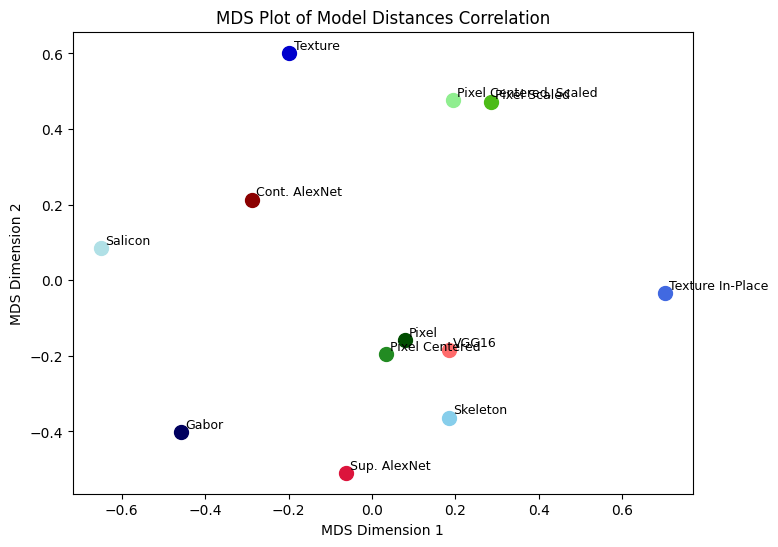

In [15]:
# Perform MDS on the correlation matrix and color each point based on model type
from sklearn.manifold import MDS
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
dissimilarity = 1 - correlation_matrix.abs()
mds_coords = mds.fit_transform(dissimilarity)
plt.figure(figsize=(8, 6))
for i, label in enumerate(df_labels_red):
    plt.scatter(mds_coords[i, 0], mds_coords[i, 1], label=label, color=colors[i], s=100)
    plt.text(mds_coords[i, 0]+0.01, mds_coords[i, 1]+0.01, label, fontsize=9)
plt.title('MDS Plot of Model Distances Correlation')
plt.xlabel('MDS Dimension 1')
plt.ylabel('MDS Dimension 2')
plt.savefig(f'{filePath}figures/{taskName}_correlation_matrix_MDS.png', dpi=300)
plt.savefig(f'{filePath}figures/{taskName}_correlation_matrix_MDS.svg', dpi=300)
plt.show()

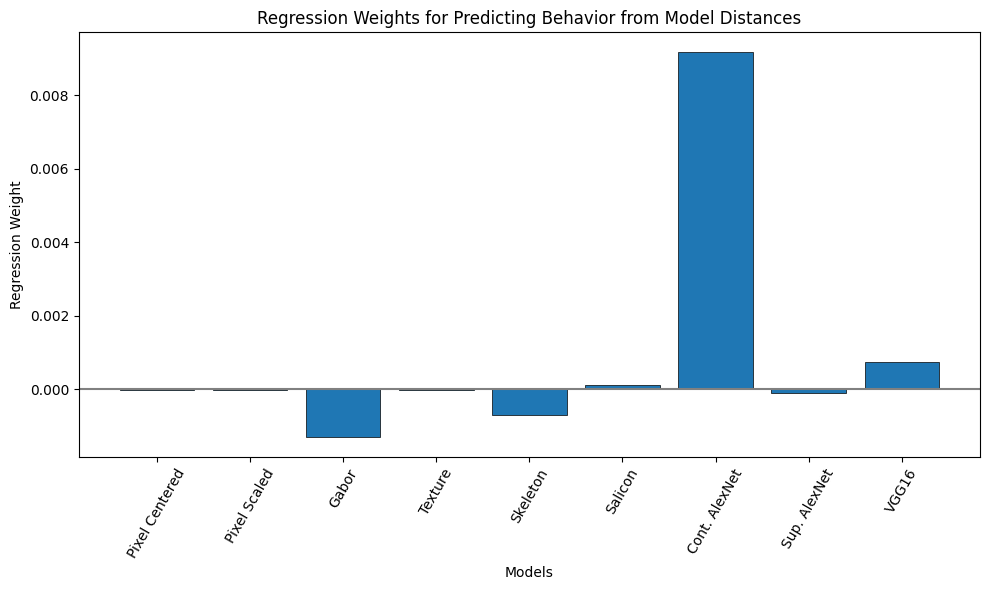

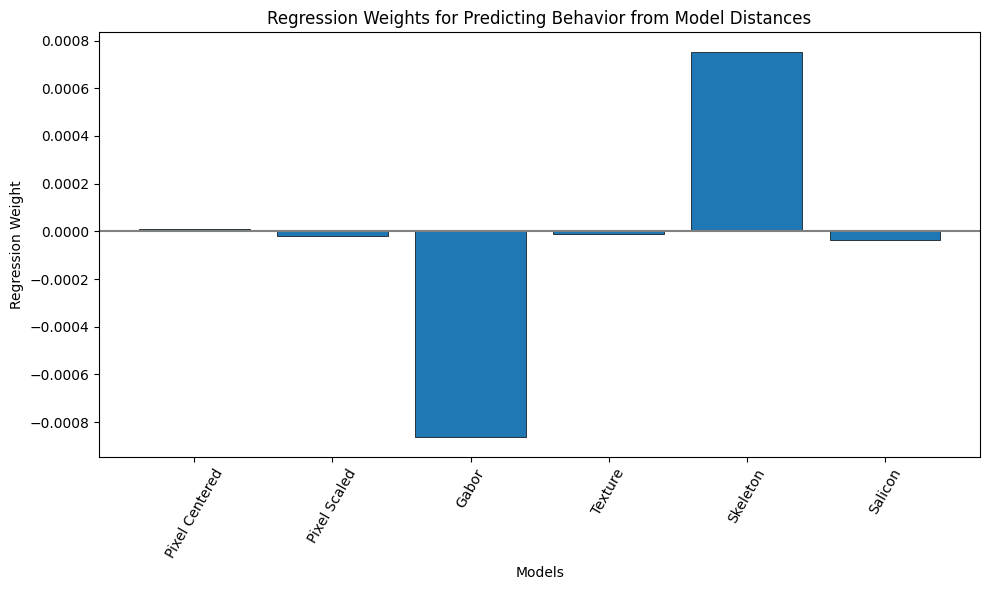

In [11]:
df_combined = pd.concat([df_pixelcenter_orig, df_pixelscale_orig, df_gabor, df_texture, df_skeleton, df_salicon, df_alexnet_cont, df_alexnet_sup, df_vgg], axis=1, ignore_index=True)
df_labels = ['Pixel Centered','Pixel Scaled', 'Gabor', 'Texture', 'Skeleton', 'Salicon', 'Cont. AlexNet', 'Sup. AlexNet', 'VGG16']

# Build regression model to predict behavior from all model distances
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

X = df_combined.values
y = df_behavior.values.ravel()

model = LinearRegression()
model.fit(X, y)
weights = model.coef_

plt.figure(figsize=(10, 6))
plt.bar(range(len(df_labels)), weights, edgecolor='black', linewidth=0.5)
plt.axhline(y=0, color='gray')
plt.xticks(range(len(df_labels)), df_labels, rotation=60)
plt.title('Regression Weights for Predicting Behavior from Model Distances')
plt.ylabel('Regression Weight')
plt.xlabel('Models')
plt.tight_layout()
# plt.savefig(f'{filePath}figures/{taskName}_regression_weights.png', dpi=300)
# plt.savefig(f'{filePath}figures/{taskName}_regression_weights.svg', dpi=300)
plt.show()

df_combined = pd.concat([df_pixelcenter_orig, df_pixelscale_orig, df_gabor, df_texture, df_skeleton, df_salicon], axis=1, ignore_index=True)
df_labels = ['Pixel Centered','Pixel Scaled', 'Gabor', 'Texture', 'Skeleton', 'Salicon']

# Build regression model to predict behavior from all model distances
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

X = df_combined.values
y = df_behavior.values.ravel()

model = LinearRegression()
model.fit(X, y)
weights = model.coef_

plt.figure(figsize=(10, 6))
plt.bar(range(len(df_labels)), weights, edgecolor='black', linewidth=0.5)
plt.axhline(y=0, color='gray')
plt.xticks(range(len(df_labels)), df_labels, rotation=60)
plt.title('Regression Weights for Predicting Behavior from Model Distances')
plt.ylabel('Regression Weight')
plt.xlabel('Models')
plt.tight_layout()
# plt.savefig(f'{filePath}figures/{taskName}_regression_weights.png', dpi=300)
# plt.savefig(f'{filePath}figures/{taskName}_regression_weights.svg', dpi=300)
plt.show()